In [2]:
import h5py

file = h5py.File('georgia_processing/AB06/ik/knee_treadmill_01_01.mat', 'r')

print(list(file.keys()))

shape = file['knee_angle_l'].shape
print(shape)

['knee_angle_l', 'knee_angle_r']
(1, 28612)


In [2]:
import h5py
import numpy as np

file = h5py.File('georgia_processing/AB06/emg/emg_treadmill_01_01.mat', 'r')
emg = np.array(file['emg'])
emg = emg.T
print(emg.shape)

(143056, 11)


In [ ]:
import os
import h5py
import numpy as np
from scipy.signal import resample

# CONFIG
ROOT = "georgia_processing"
X_all = []
y_all = []

# LOAD
for subject in os.listdir(ROOT):

    subject_path = os.path.join(ROOT, subject)

    emg_path = os.path.join(subject_path, "emg")
    ik_path  = os.path.join(subject_path, "ik")

    if not os.path.exists(emg_path) or not os.path.exists(ik_path):
        continue

    for file_name in os.listdir(emg_path):

        if not file_name.endswith(".mat"):
            continue

        try:
            # EMG
            with h5py.File(os.path.join(emg_path, file_name), 'r') as f:
                emg = np.array(f['emg']).T   # (T, 11)

            # IK
            ik_name = file_name.replace("emg_", "knee_")

            with h5py.File(os.path.join(ik_path, ik_name), 'r') as f:
                knee_r = np.array(f['knee_angle_r']).squeeze().T
                knee_l = np.array(f['knee_angle_l']).squeeze().T

            # FIX SHAPES
            knee_r = knee_r.flatten()
            knee_l = knee_l.flatten()

            # combine (T, 2)
            knee = np.stack([knee_r, knee_l], axis=1)

            # ALIGN LENGTH
            target_len = knee.shape[0]
            emg = resample(emg, target_len, axis=0)

            X_all.append(emg)
            y_all.append(knee)

        except Exception as e:
            print(f"Error in {file_name}: {e}")
            continue


# FINAL ARRAYS
X_all = np.array(X_all, dtype=object)
y_all = np.array(y_all, dtype=object)

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)

X shape: (66,)
y shape: (66,)


In [7]:
print("X shape:", X_all[0].shape)
print("y shape:", y_all[0].shape)

X shape: (28612, 11)
y shape: (28612, 2)


In [22]:
emg_columns = [
    "gastrocmed",
    "tibialisanterior",
    "soleus",
    "vastusmedialis",
    "vastuslateralis",
    "rectusfemoris",
    "bicepsfemoris",
    "semitendinosus",
    "gracilis",
    "gluteusmedius",
    "rightexternaloblique"
]
import pandas as pd

df_list = []

for i in range(len(X_all)):
    df_emg = pd.DataFrame(X_all[i], columns=emg_columns)
    df_knee = pd.DataFrame(y_all[i], columns=["knee_angle_r", "knee_angle_l"])

    df = pd.concat([df_emg, df_knee], axis=1)
    df_list.append(df)

df_list[0]

,gastrocmed,tibialisanterior,soleus,vastusmedialis,vastuslateralis,rectusfemoris,bicepsfemoris,semitendinosus,gracilis,gluteusmedius,rightexternaloblique,knee_angle_r,knee_angle_l
0,0.011090,-0.010827,-0.003254,0.000241,-0.009604,0.004001,0.029272,-0.005759,-0.009161,-0.017718,-0.038232,-12.014975,-7.330916
1,-0.022353,0.007982,0.077124,-0.000491,0.004814,-0.002730,-0.003008,0.013489,0.000803,0.032669,-0.013494,-11.988378,-7.395329
2,0.009467,-0.005704,-0.090535,-0.001594,-0.004614,0.005183,0.000265,-0.009563,-0.001771,-0.025379,-0.007409,-11.977733,-7.378882
3,-0.009379,0.001325,0.009614,0.003310,0.008492,-0.007639,0.003043,0.006101,0.002230,0.004345,-0.014098,-11.975535,-7.373596
4,0.015126,-0.007549,0.007095,-0.000460,-0.006717,0.003138,-0.001174,-0.005158,-0.003612,-0.002793,0.068978,-11.959454,-7.360056
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28607,-0.005370,0.012063,-0.050317,-0.001254,0.000287,0.002006,-0.009183,-0.006863,-0.005158,0.014909,0.007948,-26.466435,-10.644449
28608,0.009685,-0.015005,0.031455,-0.001497,0.001802,-0.002750,-0.014094,0.005001,0.002757,0.019046,-0.009564,-25.842397,-10.660224
28609,-0.008607,0.001887,0.148131,0.002362,-0.000358,0.000677,0.021808,-0.009621,0.001457,-0.029890,0.024911,-25.289729,-10.675871
28610,0.006232,-0.004239,-0.089416,0.002484,-0.000468,0.001046,-0.034794,0.003982,0.001079,0.004240,0.075837,-24.799233,-10.692917


In [23]:
len(df_list)

66

هما استخدموا 4 channels بس:

* biceps femoris
* rectus femoris
* semitendinosus
* vastus medialis

In [80]:
channels = [
    "bicepsfemoris",
    "rectusfemoris",
    "semitendinosus",
    "vastusmedialis"
    ]

ik = [
    "knee_angle_r",
    "knee_angle_l"
]

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_emg_signals(df, title="EMG Signals"):

    # Create subplots
    fig, axes = plt.subplots(len(channels), 1, figsize=(16, 10), sharex=True)

    fig.suptitle(title, fontsize=14, fontweight="bold")

    for i, channel in enumerate(channels):
        ax = axes[i]

        ax.plot(df.index, df[channel], color= "#d78946", linewidth=1.2)

        ax.set_ylabel(channel, fontsize=10, rotation=0, labelpad=40)
        ax.grid(True, linestyle="--", alpha=0.4)

        # clean style
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Time (samples)", fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_ik_signals(df, title="Knee Angles"):
    fig, axes = plt.subplots(len(ik), 1, figsize=(16, 5), sharex=True)

    fig.suptitle(title, fontsize=14, fontweight="bold")

    for i, channel in enumerate(ik):
        ax = axes[i]

        ax.plot(df.index, df[channel], color= "#d78946", linewidth=1.2)

        ax.set_ylabel(channel, fontsize=10, rotation=0, labelpad=40)
        ax.grid(True, linestyle="--", alpha=0.4)

        # clean style
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Time (samples)", fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


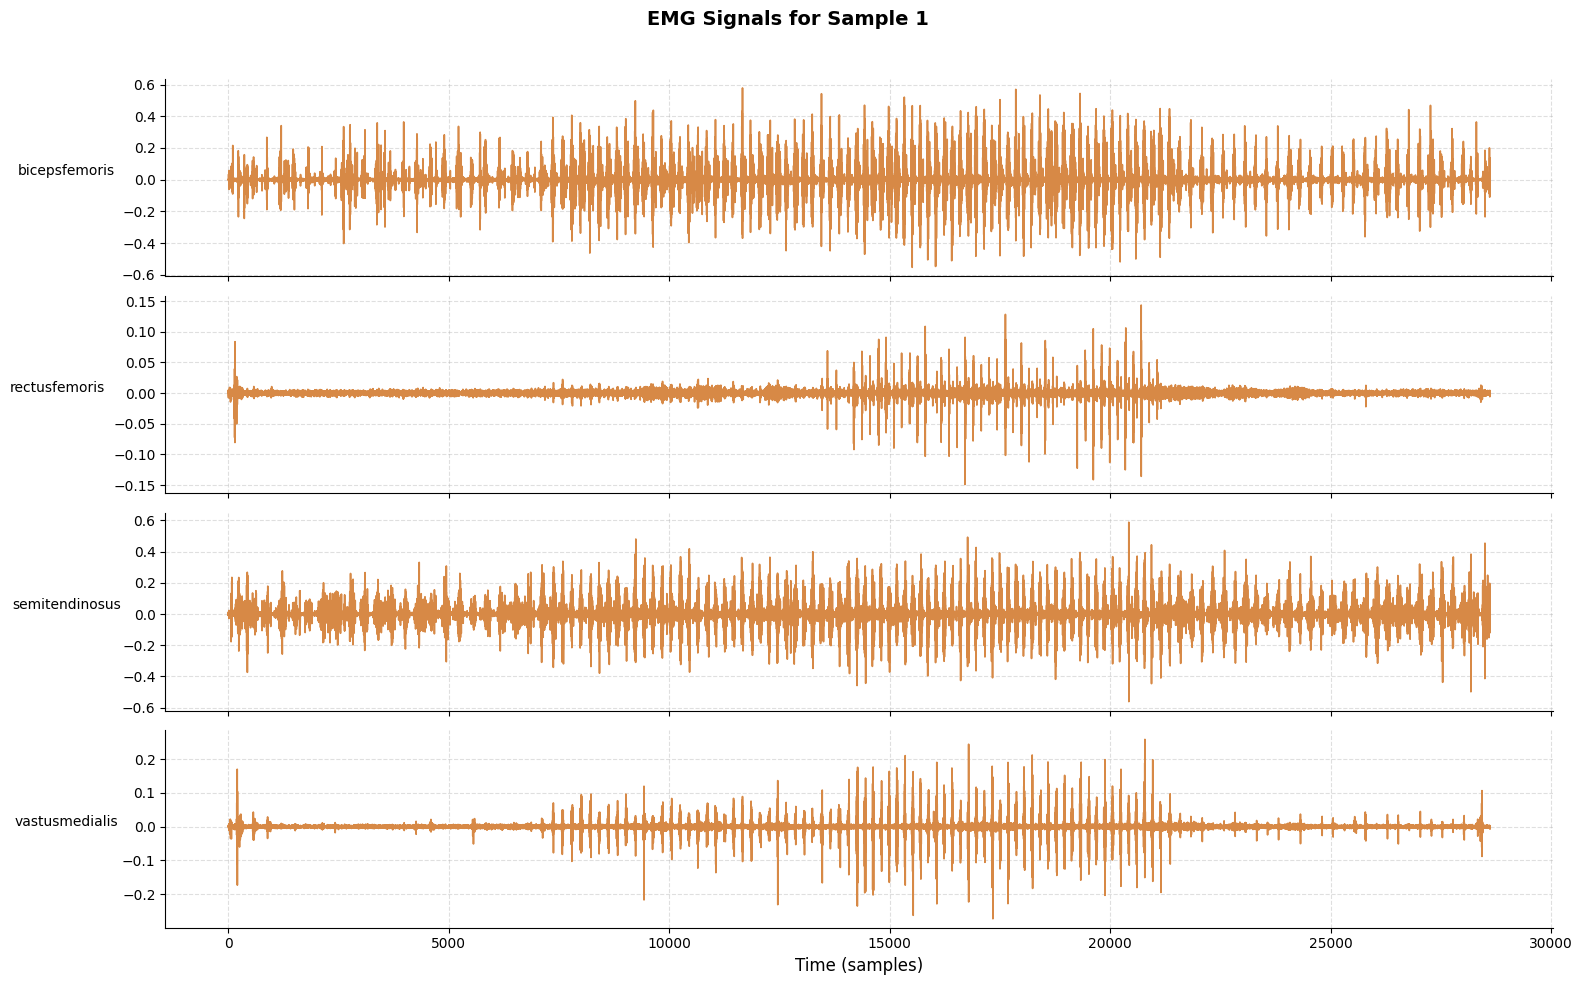

In [82]:
plot_emg_signals(df_list[0], title="EMG Signals for Sample 1")

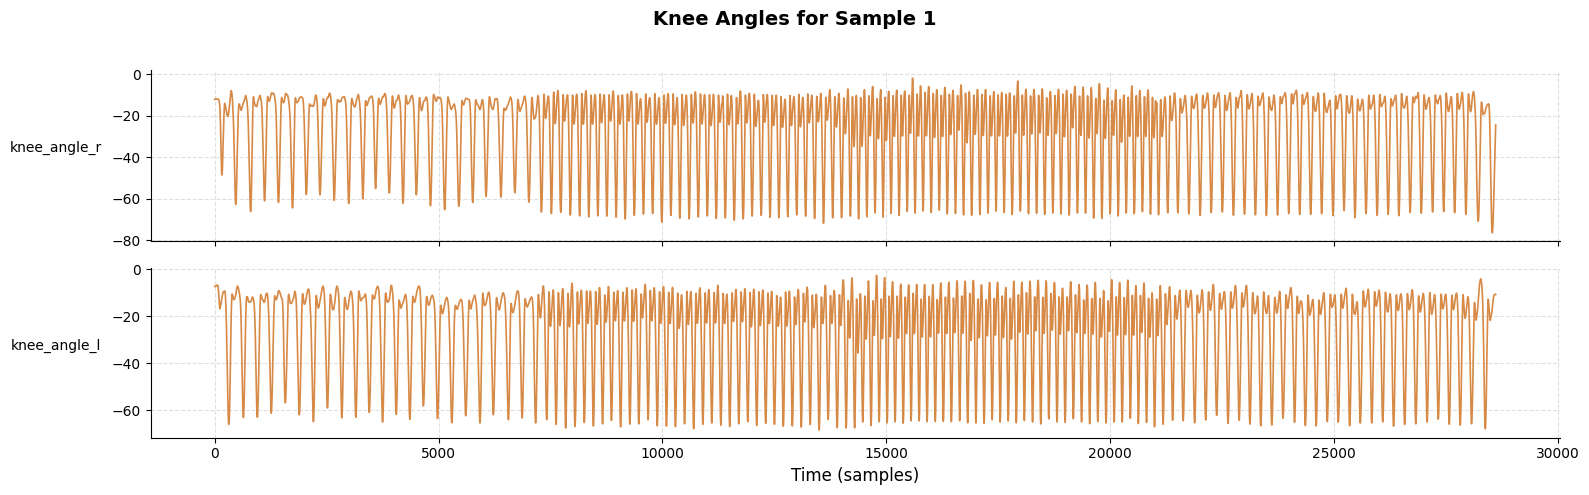

In [85]:
plot_ik_signals(df_list[0], title="Knee Angles for Sample 1")

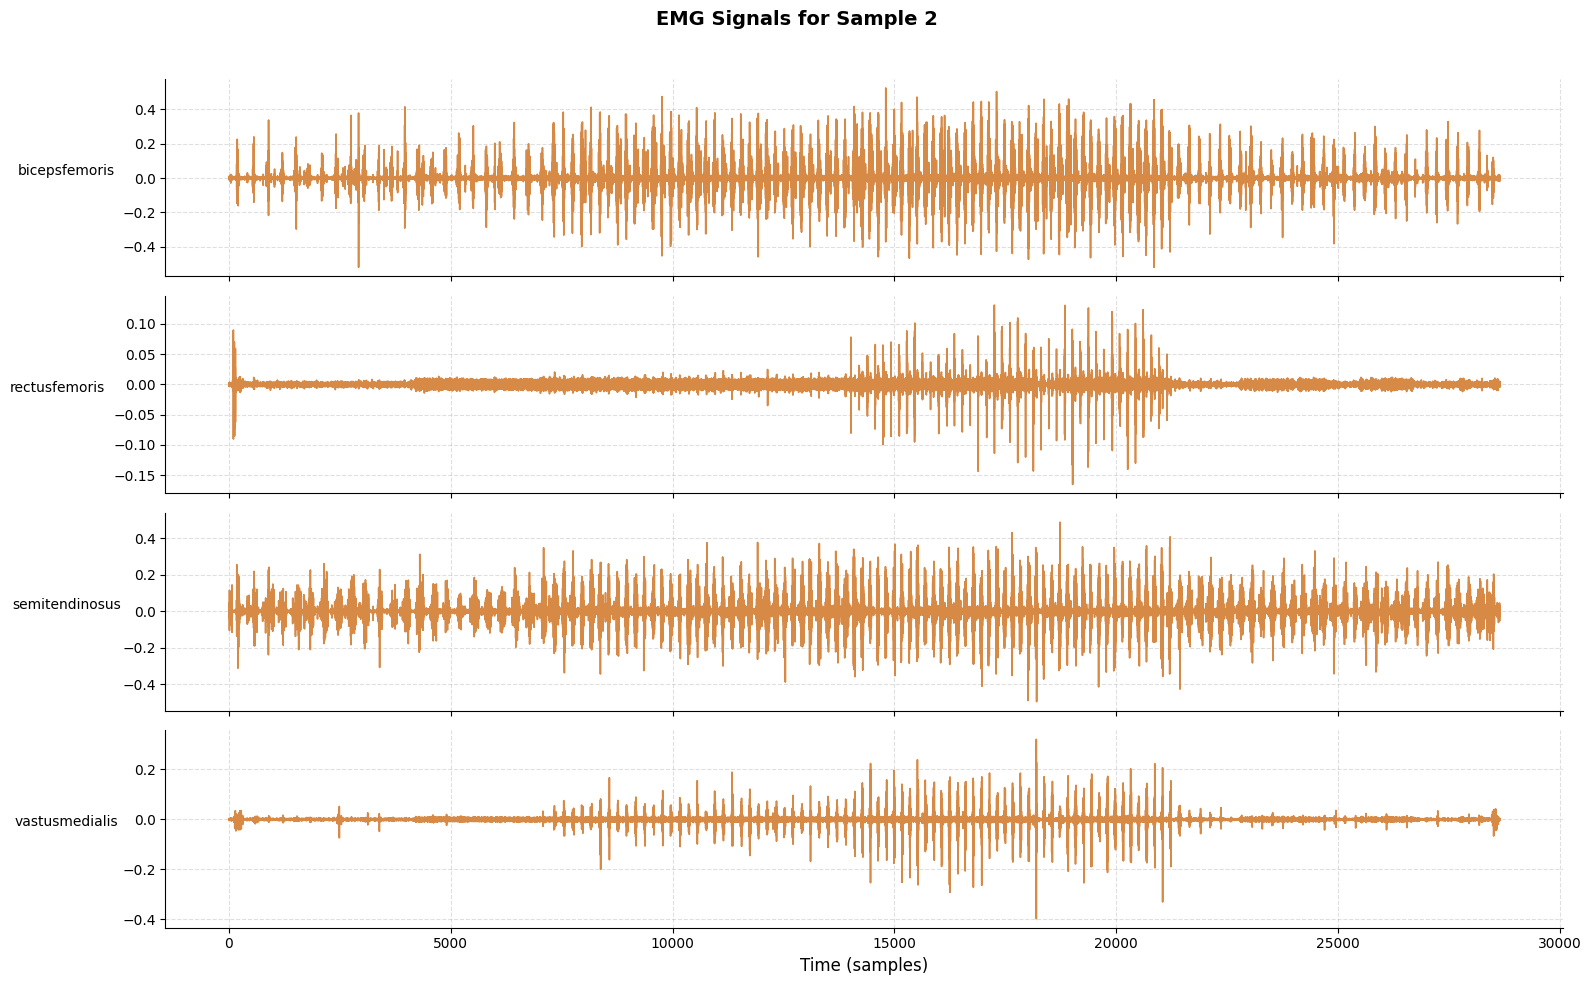

In [27]:
plot_emg_signals(df_list[1], title="EMG Signals for Sample 2")

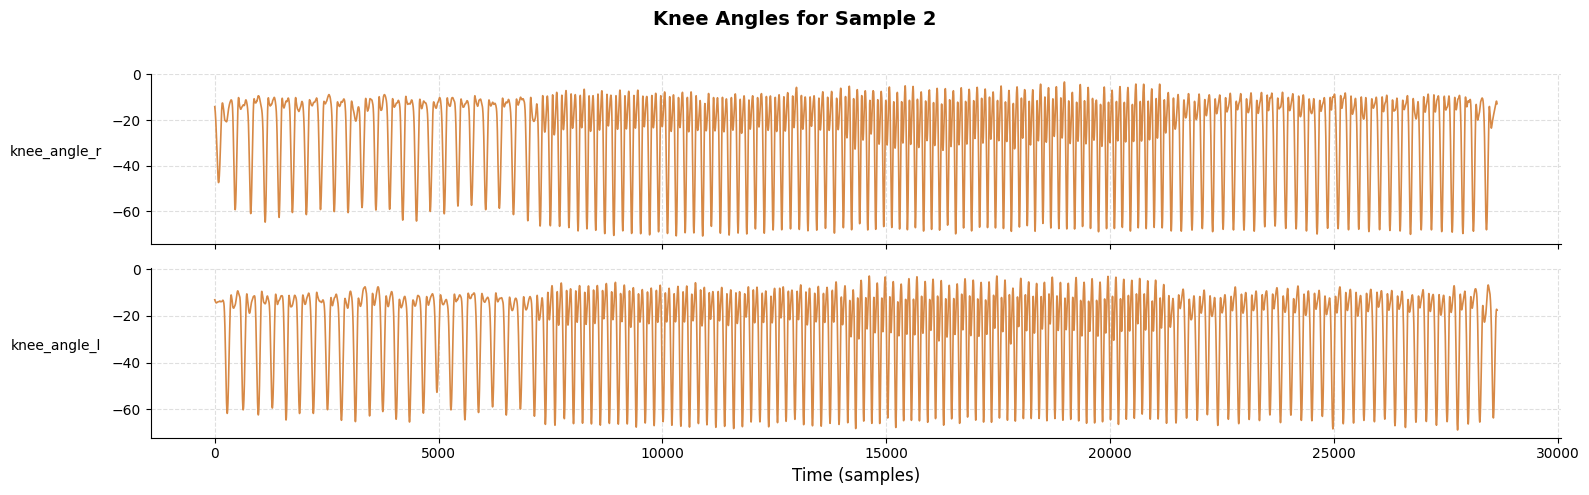

In [87]:
plot_ik_signals(df_list[1], title="Knee Angles for Sample 2")

## Processing

In [ ]:
def plot_emg_difference(emg, emg_filtered, channel):
    # Plot original vs filtered signals for one channel
    channel_index = channels.index(channel)
    plt.figure(figsize=(15, 6))
    plt.subplot(2, 1, 1)
    plt.plot(emg.index, emg.iloc[:, channel_index], label=f'Original {channel}', color='blue')
    plt.ylabel(channel, fontsize=12, rotation=0, labelpad=30)
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(emg_filtered.index, emg_filtered.iloc[:, channel_index], label=f'Filtered {channel}', color='orange')
    plt.ylabel(channel, fontsize=12, rotation=0, labelpad=30)
    plt.legend()

#### 1- high-pass Butterworth filter

And this helps us to remove the movement of the body and thus focus on the analysis and the minutes and remove any drift
Its purpose is to reduce low frequencies (low-frequency noise) i.e. here the cutting frequency = **20 Hz**

In [104]:
from scipy import signal

def apply_highpass(data: np.ndarray, fs: float = 1000.0, cutoff: float = 20.0, order: int = 4):
    """Apply a high-pass Butterworth filter to EMG data."""
    
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = signal.butter(order, norm_cutoff, btype="highpass")
    df_filtered = pd.DataFrame(signal.filtfilt(b, a, data, axis=0))
    return df_filtered

In [100]:
emg = df_list[0][channels]
emg_filtered = apply_highpass(emg.values)

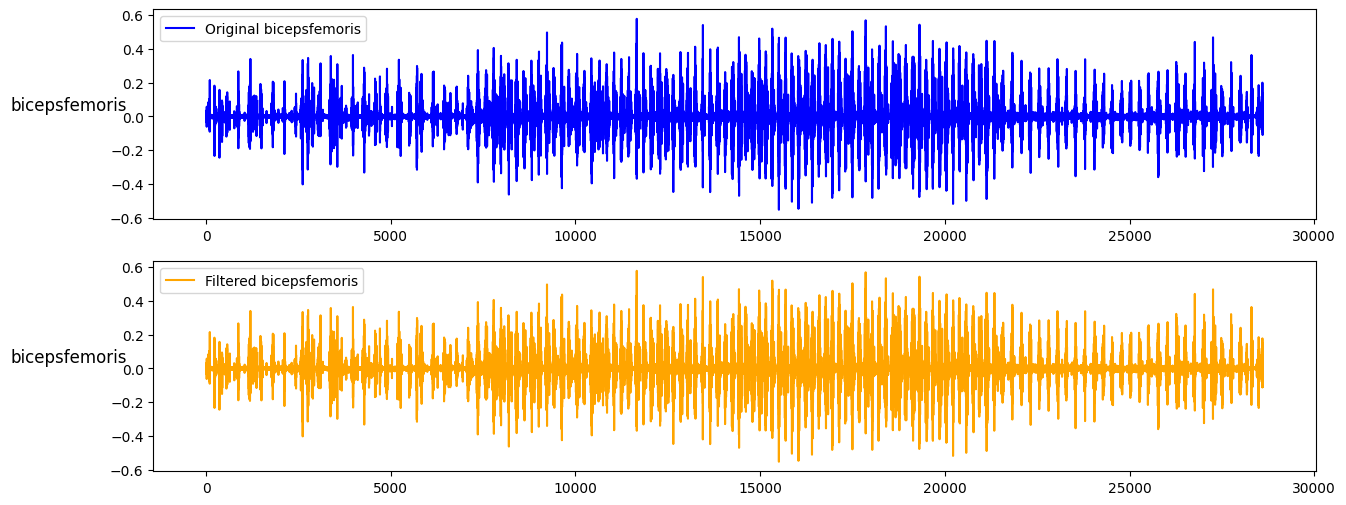

In [101]:
plot_emg_difference(emg, emg_filtered, channel="bicepsfemoris")

#### 2 - Taking absolute value

The goal is to convert the signal to positive values only and represent the signal strength instead of the remaining vector.

In [39]:
def rectify(data: np.ndarray):
    """Rectify EMG signal by taking the absolute value."""
    return pd.DataFrame(np.abs(data))

In [42]:
emg = df_list[0][channels]
emg_filtered = rectify(emg.values)

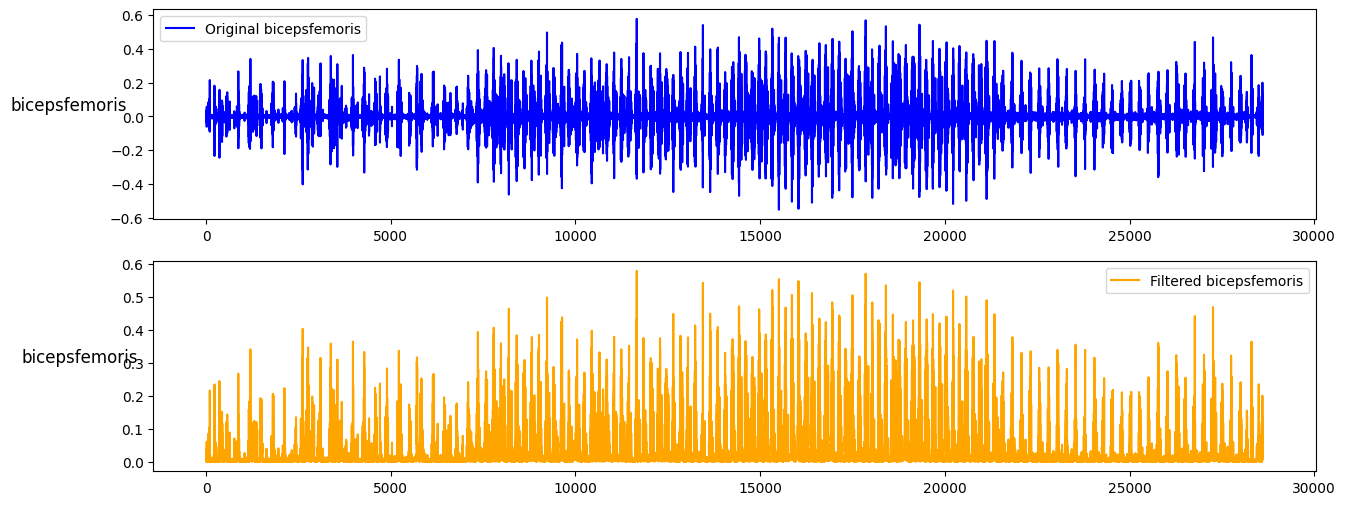

In [43]:
plot_difference(emg, emg_filtered, channel='bicepsfemoris')

#### 3 - low-pass Butterworth filter

The purpose of this is to smooth the signal, which means that we will make a filter (Butterworth 2nd order (Cutoff = 3–6 Hz).



In [59]:
def apply_lowpass(data: np.ndarray, fs: float = 1000.0, low=20, high=450, order: int = 2):
    """Apply a low-pass Butterworth filter to EMG data."""
    nyq = 0.5 * fs
    b, a = signal.butter(order, [low/nyq, high/nyq], btype="bandpass")
    return pd.DataFrame(signal.filtfilt(b, a, data, axis=0))


In [60]:
emg = df_list[0][channels]
emg_filtered = apply_lowpass(emg.values)

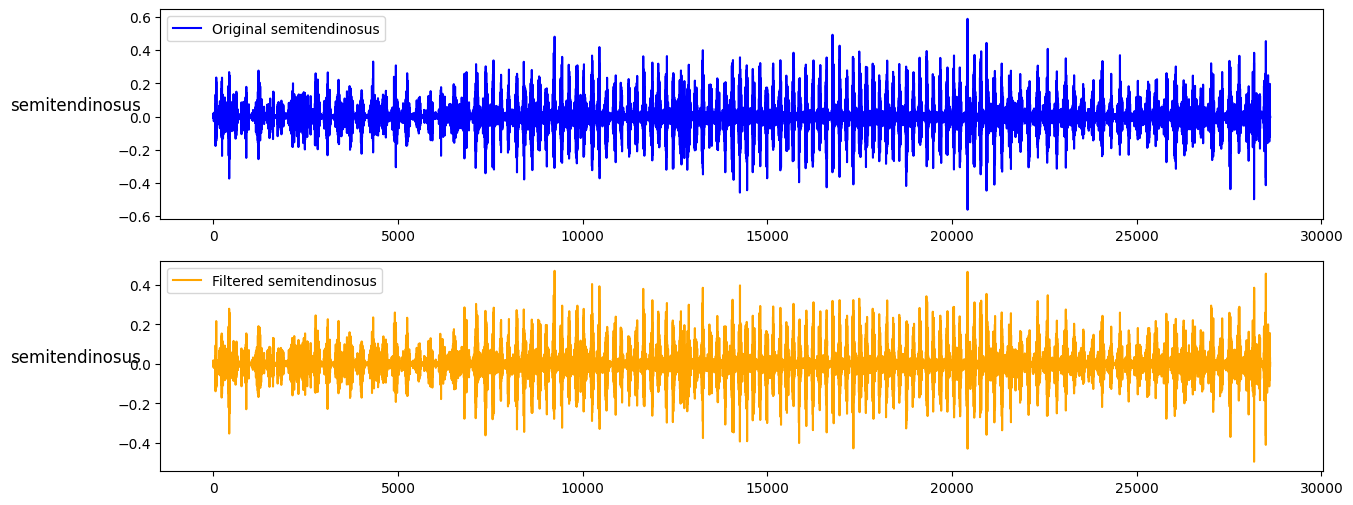

In [61]:
plot_difference(emg, emg_filtered, channel='semitendinosus')

#### 4 - Normalize EMG per channel

Its goal is to standardize data, and the benefit is to improve the model’s performance and reduce people’s differences

In [49]:
def normalize_emg(data: np.ndarray, eps: float = 1e-8):
    """Z-score normalize EMG per channel (mean=0, std=1).

    Normalization is performed along the time axis (axis=0):
    - For shape (n_samples,), computes global mean/std.
    - For shape (n_samples, n_channels), computes mean/std per channel.
    """
    mean = np.mean(data, axis=0, keepdims=True)
    std = np.std(data, axis=0, keepdims=True)
    return pd.DataFrame((data - mean) / (std + eps))


In [50]:
emg = df_list[0][channels]
emg_filtered = normalize_emg(emg.values)

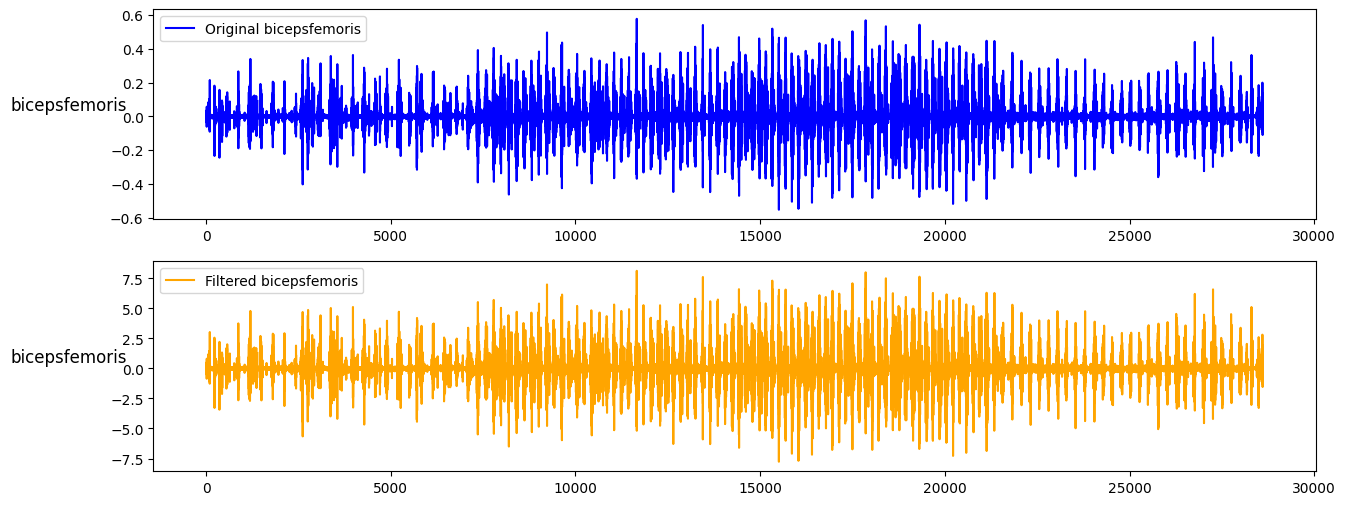

In [51]:
plot_difference(emg, emg_filtered, channel='bicepsfemoris')

In [65]:
def window_signal(data: np.ndarray, window_size: int, overlap: float = 0.0) -> np.ndarray:
    """Segment data into overlapping windows."""
    if not (0.0 <= overlap < 1.0):
        raise ValueError("overlap must be in [0, 1).")

    step = int(window_size * (1.0 - overlap))
    if step <= 0:
        raise ValueError("Step size must be positive. Reduce overlap or window_size.")

    n_samples = data.shape[0]
    indices = []
    start = 0
    while start + window_size <= n_samples:
        indices.append((start, start + window_size))
        start += step

    if len(indices) == 0:
        raise ValueError("Not enough samples for a single window.")

    windows = []
    for start, end in indices:
        segment = data[start:end]
        windows.append(segment)

    return np.stack(windows, axis=0)

In [66]:
emg = df_list[0][channels]
emg_windowed = window_signal(emg.values, window_size=200, overlap=0.5)

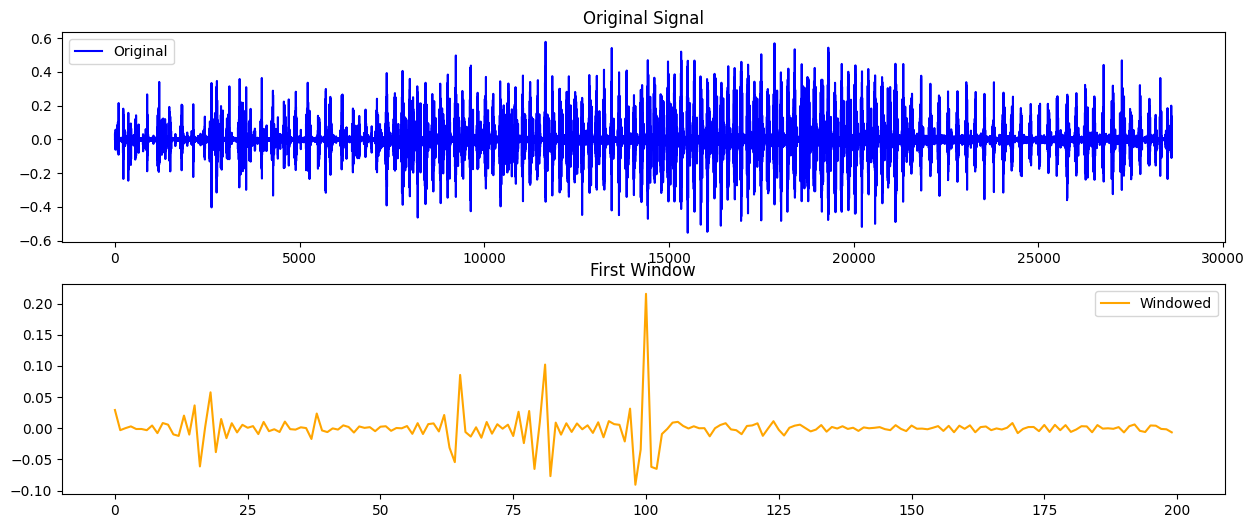

In [67]:
plt.figure(figsize=(15, 6))

# Original
plt.subplot(2, 1, 1)
plt.plot(emg.iloc[:, 0], label='Original', color='blue')
plt.title('Original Signal')
plt.legend()

# Windowed (first window)
plt.subplot(2, 1, 2)
plt.plot(emg_windowed[0][:, 0], label='Windowed', color='orange')
plt.title('First Window')
plt.legend()

plt.show()

### Finally apply the processing pipeline

```plain text
Raw Signal
   ↓
High-pass Filter
   ↓
Rectification
   ↓
Low-pass Filter
   ↓
Normalization
   ↓
Model Input

```

In [ ]:
def preprocess_emg(
    raw_emg: np.ndarray,
    original_fs: float = 1000.0,
    highpass_cutoff: float = 20.0,
    lowpass_order: int = 4,
    window_size_samples: int = 200,
    window_overlap: float = 0.0,
):
    """Full EMG preprocessing pipeline (clean NumPy version)."""

    # 1. High-pass
    hp = apply_highpass(raw_emg, fs=original_fs, cutoff=highpass_cutoff)

    # 2. Rectify
    rect = np.abs(hp.values)

    # 3. Low-pass
    lp = apply_lowpass(rect, fs=original_fs,  low=20, high=450, order=lowpass_order)

    # 4. Normalize
    mean = np.mean(lp.values, axis=0, keepdims=True)
    std = np.std(lp.values, axis=0, keepdims=True)
    norm = (lp.values - mean) / (std + 1e-8)

    # 5. Windowing
    windows = window_signal(norm, window_size=window_size_samples, overlap=window_overlap)

    return windows

In [71]:
emg = df_list[0][channels]
windows = preprocess_emg(emg.values, window_overlap=0.5)

print(windows.shape)

(285, 200, 4)


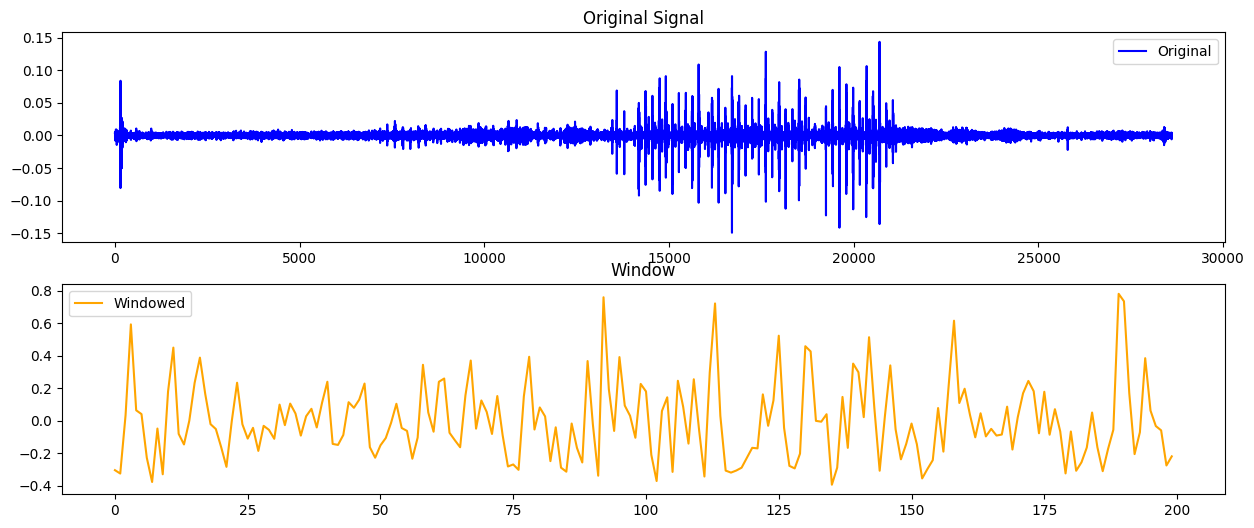

In [72]:
plt.figure(figsize=(15, 6))

# Original
plt.subplot(2, 1, 1)
plt.plot(emg.iloc[:, 1], label='Original', color='blue')
plt.title('Original Signal')
plt.legend()

# Windowed (first window)
plt.subplot(2, 1, 2)
plt.plot(windows[13][:, 1], label='Windowed', color='orange')
plt.title('Window')
plt.legend()

plt.show()

These preprocessing steps are commonly employed 
in studies that predict lower-limb joint angles using EMG signals

### Apply the proessing on entire data

In [ ]:
def process_dataset(df_list):
    all_X = []
    all_y = []

    for df in df_list:

        emg = df[channels].values
        knee = df['knee_angle_r'].values.reshape(-1, 1)

        X = preprocess_emg(emg, window_overlap=0.0)

        # ===== preprocess Knee =====
        factor = int(1000 / 100)
        knee_down = signal.decimate(knee, factor, axis=0, zero_phase=True)

        # windowing
        y = window_signal(knee_down, window_size=200, overlap=0.0)

        all_X.append(X)
        all_y.append(y)

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)

    return X, y

In [108]:
X, y = process_dataset(df_list)
print(X.shape, y.shape)

(9438, 200, 4) (924, 200, 1)


In [109]:
# save preprocessed data
np.savez("georgia_processed_data.npz", X=X, y=y)